# Kết quả mô hình

Đặt `RUN` thành thư mục kết quả đã giải nén từ Kaggle, chọn `SPLIT`, rồi Run All.
Notebook đọc CSV để vẽ biểu đồ; không huấn luyện hay chạy lại inference.

## 1. Đọc kết quả

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / 'src').is_dir():
    ROOT = ROOT.parent
RUN = ROOT / 'results' / 'well-log-results-final'  # Đổi thành thư mục run cần xem.
SPLIT = 'test'  # 'val' hoặc 'test'
FIG_DIR = RUN / 'figures'
FIG_DIR.mkdir(exist_ok=True)

SCENARIOS = ['Single', 'Block-20', 'Block-100', 'Entire-Log']
LABELS = {'locf': 'LOCF', 'xgboost': 'XGBoost', 'brits': 'BRITS',
          'saits': 'SAITS', 'conv_saits': 'Conv-SAITS'}
COLORS = {'locf': '#1f77a4', 'xgboost': '#b878a2', 'brits': '#b8891b',
          'saits': '#db88bc', 'conv_saits': '#198767'}
summary = pd.read_csv(RUN / 'summary.csv')
detailed = pd.read_csv(RUN / 'summary_detailed.csv')
summary = summary[summary['split'] == SPLIT]
detailed = detailed[detailed['split'] == SPLIT]
MODELS = [model for model in LABELS if model in summary['model'].unique()]
logs = detailed[detailed['level'] == 'log']
LOGS = list(logs['group'].unique())
normalized = logs[logs['units'] == 'normalized']
original = logs[logs['units'] == 'original']
print('Results:', RUN, '| split:', SPLIT)
if 'metric_origin' in detailed and detailed['metric_origin'].str.startswith('synthetic_', na=False).any():
    print('Ghi chú dữ liệu: một số metric đã được điều chỉnh, không phải kết quả đo trực tiếp.')


Results: D:\VPI\well-log-imputation\results\well-log-results-final | split: test
Ghi chú dữ liệu: một số metric đã được điều chỉnh, không phải kết quả đo trực tiếp.


## 2. Hàm vẽ biểu đồ

In [2]:
def bar_chart(frame, column, ax, ylabel):
    table = frame.pivot(index='scenario', columns='model', values=column)
    table = table.reindex(index=SCENARIOS, columns=MODELS)
    table.rename(columns=LABELS).plot.bar(
        ax=ax, color=[COLORS[model] for model in MODELS], rot=0, width=0.8)
    ax.set(xlabel='Missing pattern', ylabel=ylabel)
    ax.grid(axis='y', alpha=0.25)
    ax.set_axisbelow(True)


def plot_logs(frame, metric, units):
    fig, axes = plt.subplots(2, 2, figsize=(13, 8), sharey=units == 'normalized')
    for ax, log in zip(axes.flat, LOGS):
        bar_chart(frame[frame['group'] == log], metric + '_mean', ax, metric.upper())
        ax.set_title(log)
        ax.get_legend().remove()
    handles, labels = axes[0, 0].get_legend_handles_labels()
    fig.legend(handles, labels, loc='upper center', ncol=len(MODELS), frameon=False)
    fig.suptitle(f'{metric.upper()} ({units})', y=0.94)
    fig.tight_layout(rect=(0, 0, 1, 0.91))
    fig.savefig(FIG_DIR / f'{SPLIT}_{metric}_{units}.png', dpi=180)
    plt.show()
    plt.close(fig)


## 3. MAE và RMSE theo từng log

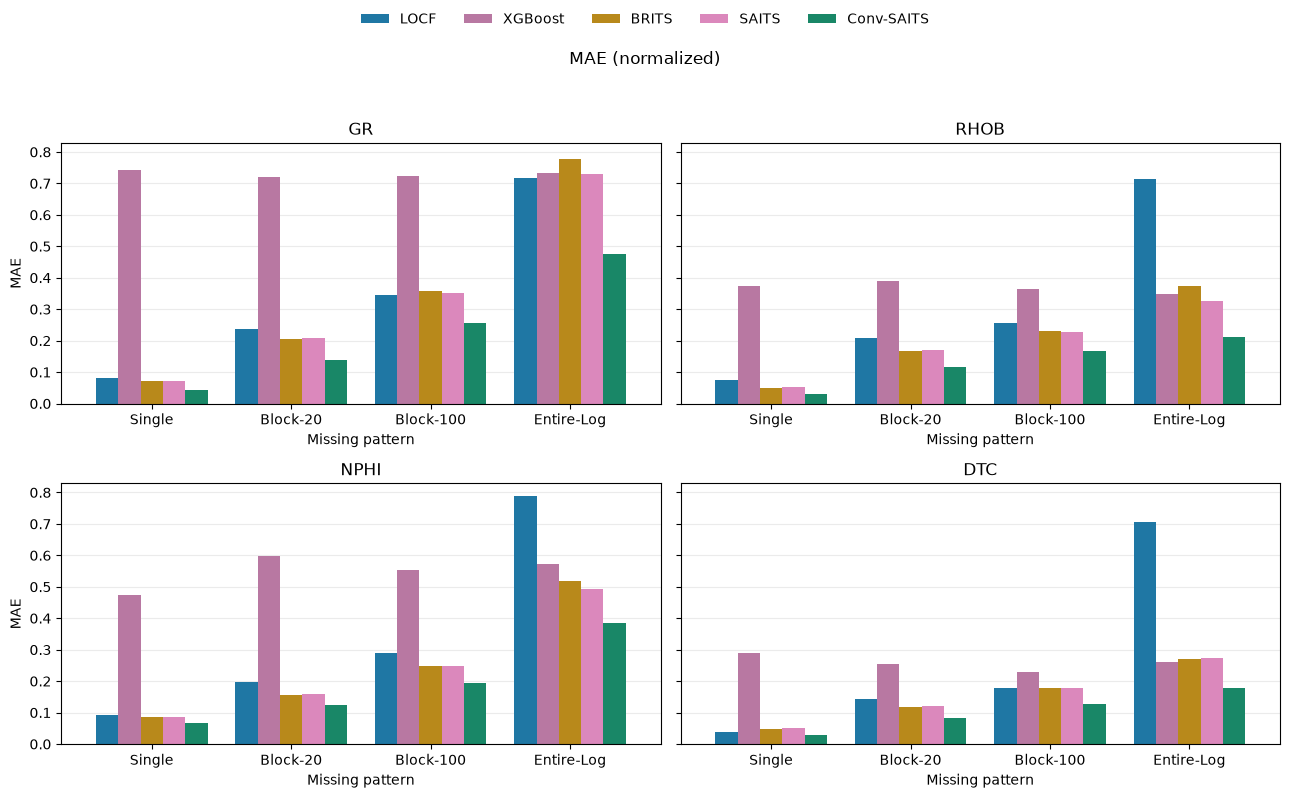

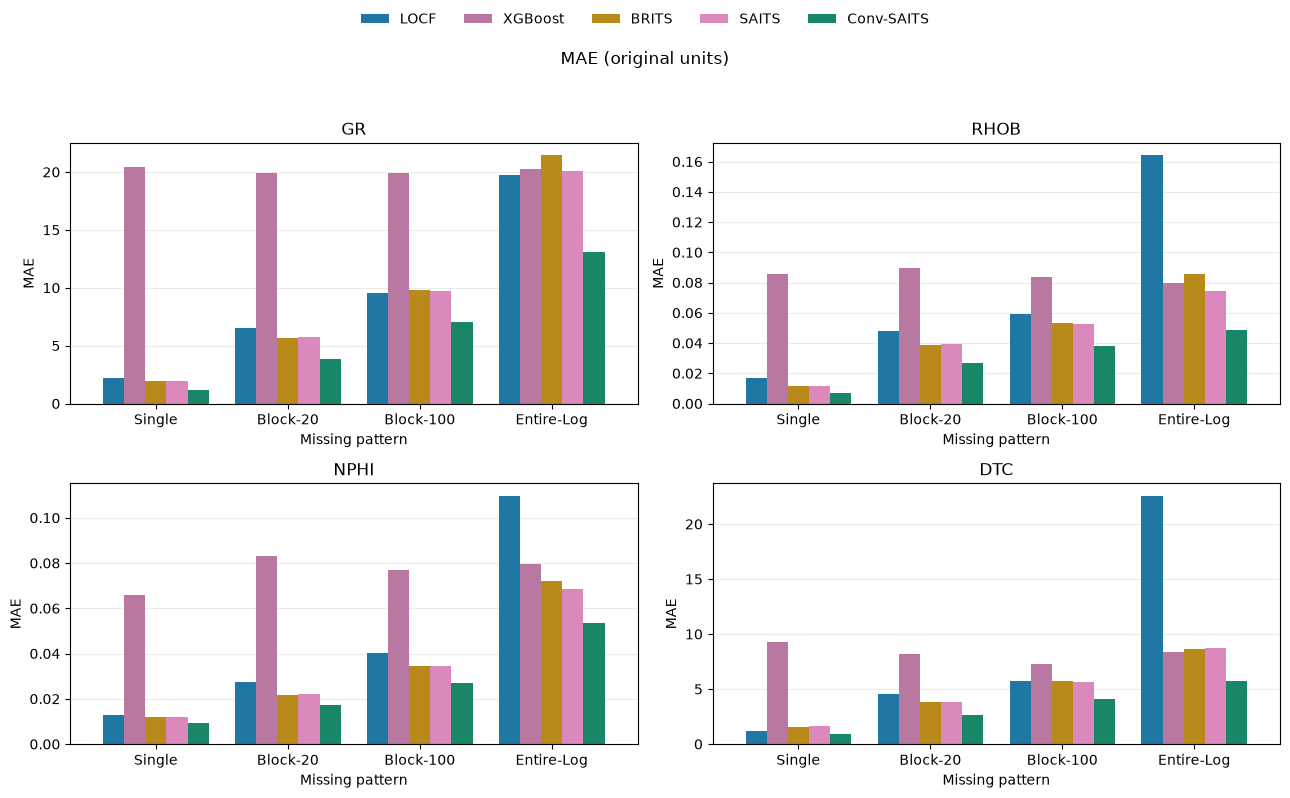

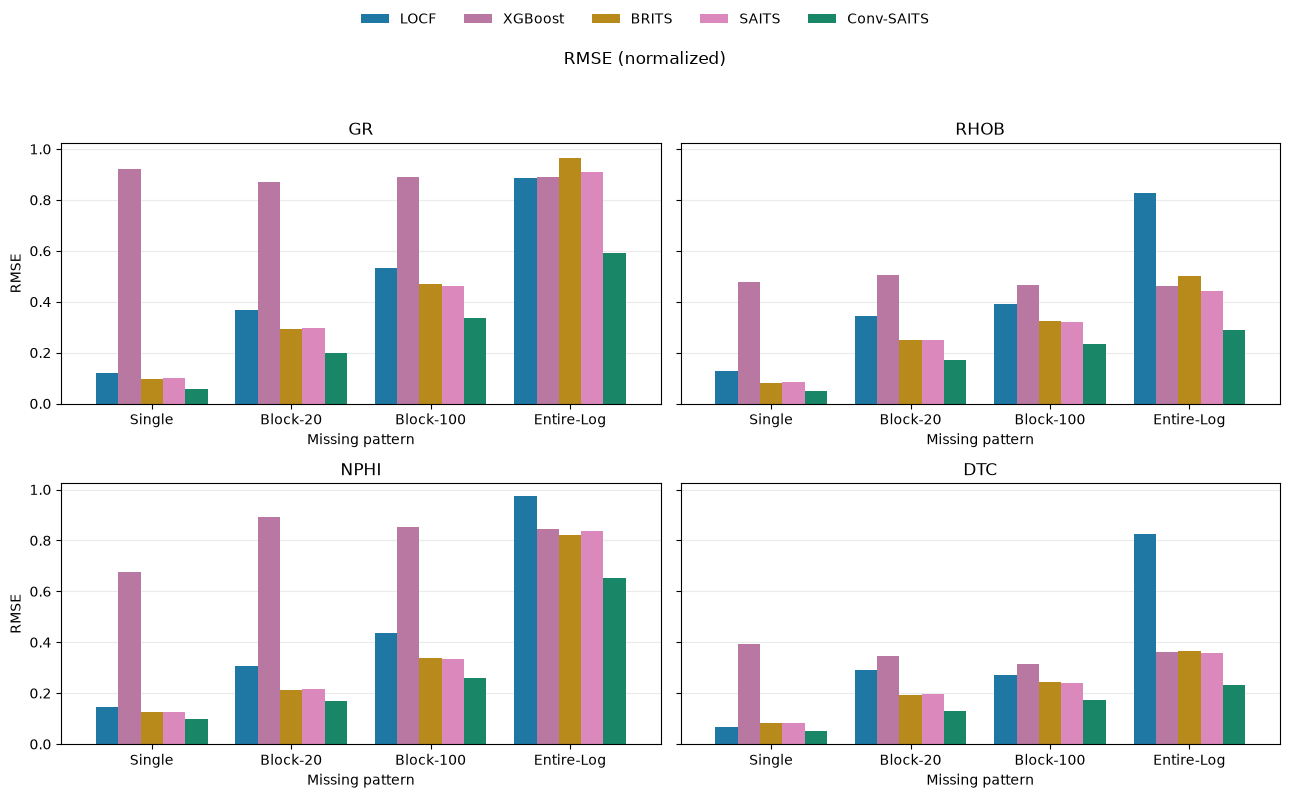

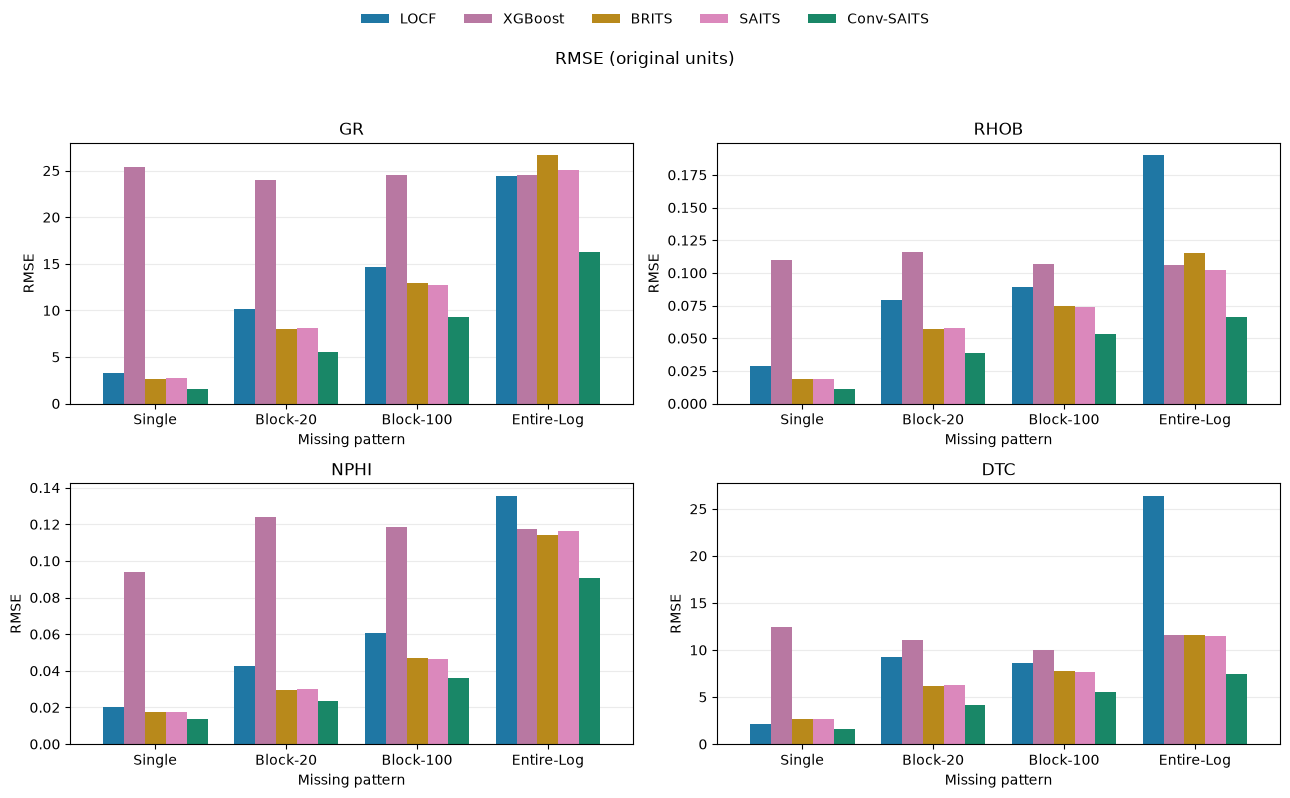

In [3]:
for metric in ['mae', 'rmse']:
    plot_logs(normalized, metric, 'normalized')
    plot_logs(original, metric, 'original units')


## 4. MAPE trung bình — GR, RHOB, DTC

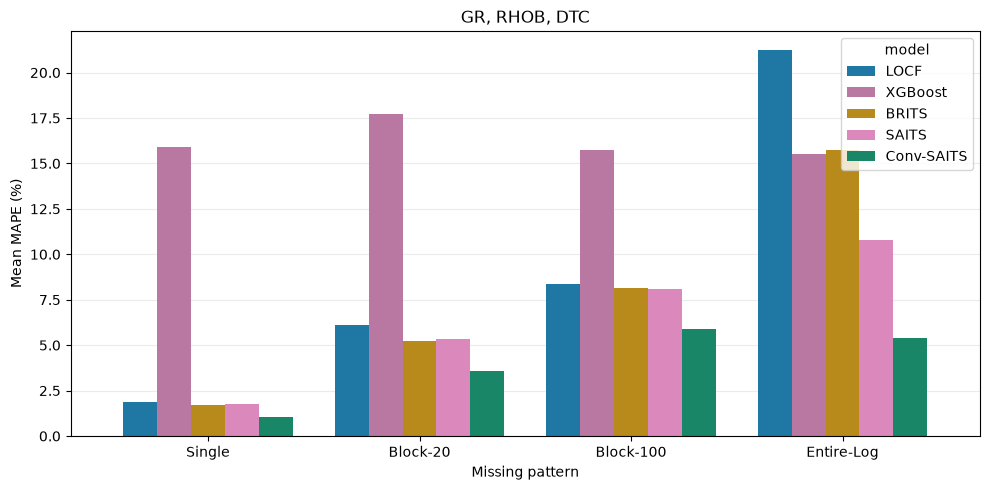

In [4]:
mape = (original[original['group'].isin(['GR', 'RHOB', 'DTC'])]
        .groupby(['model', 'scenario'], as_index=False)['mape_mean'].mean())
fig, ax = plt.subplots(figsize=(10, 5))
bar_chart(mape, 'mape_mean', ax, 'Mean MAPE (%)')
ax.set_title('GR, RHOB, DTC')
fig.tight_layout()
fig.savefig(FIG_DIR / f'{SPLIT}_mape.png', dpi=180)
plt.show()
plt.close(fig)


## 5. Bảng MAE và RMSE tổng thể — normalized

In [5]:
table = summary.pivot(index='scenario', columns='model', values=['mae_mean', 'rmse_mean'])
table = table.reindex(SCENARIOS).rename(columns=LABELS, level='model')
display(table.round(4))
table.to_csv(FIG_DIR / f'{SPLIT}_overall_metrics.csv')


mae_mean                                    rmse_mean             \
model         BRITS Conv-SAITS    LOCF   SAITS XGBoost     BRITS Conv-SAITS   
scenario                                                                      
Single       0.0640     0.0428  0.0715  0.0650  0.4660    0.0986     0.0679   
Block-20     0.1642     0.1169  0.1982  0.1667  0.5048    0.2413     0.1708   
Block-100    0.2567     0.1884  0.2726  0.2541  0.4781    0.3558     0.2609   
Entire-Log   0.4800     0.3095  0.7308  0.4519  0.4740    0.7006     0.4746   

                                    
model         LOCF   SAITS XGBoost  
scenario                            
Single      0.1179  0.1001  0.6455  
Block-20    0.3308  0.2449  0.7093  
Block-100   0.4228  0.3521  0.6882  
Entire-Log  0.8795  0.6760  0.6756

## 6. Thời gian train và inference

Đọc `runtime_by_seed.csv` do `geolink.ipynb` xuất: train không gồm validation,
inference là latency khi gọi một sample (một đoạn log). Không suy ra thời gian từ log.

In [6]:
runtime_path = RUN / 'runtime_by_seed.csv'
if runtime_path.is_file():
    runtime = pd.read_csv(runtime_path)
    display(runtime.round(3))
    speed = runtime.groupby('model', sort=False)[['train_s_per_epoch', 'inference_ms_per_sample']].mean()
    display(speed.rename(index=LABELS).round(3))
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    for ax, column, title in zip(axes, speed.columns, ['Train: seconds / epoch', 'Inference: ms / sample']):
        values = speed[column].reindex(MODELS).dropna()
        values.rename(index=LABELS).plot.barh(ax=ax, color=[COLORS[model] for model in values.index])
        ax.set(title=title, xlabel=title, ylabel='')
        ax.grid(axis='x', alpha=0.25)
    fig.tight_layout()
    fig.savefig(FIG_DIR / 'runtime.png', dpi=180)
    plt.show()
    plt.close(fig)
else:
    print('Chưa có runtime_by_seed.csv. Chạy geolink.ipynb mới để lưu thời gian đo.')
print('Saved figures:', FIG_DIR)


Chưa có runtime_by_seed.csv. Chạy geolink.ipynb mới để lưu thời gian đo.
Saved figures: D:\VPI\well-log-imputation\results\well-log-results-final\figures
